In [10]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [11]:
!pip install opencv-python

In [12]:
pip install opencv-python pillow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


Notice: 'cameraman.tif' not found. Creating a sample image to proceed...
Notice: 'lena_gray_256.tif' not found. Creating a sample image to proceed...


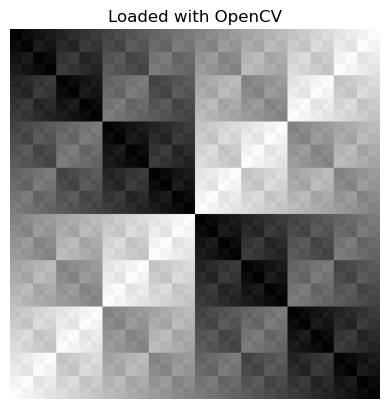

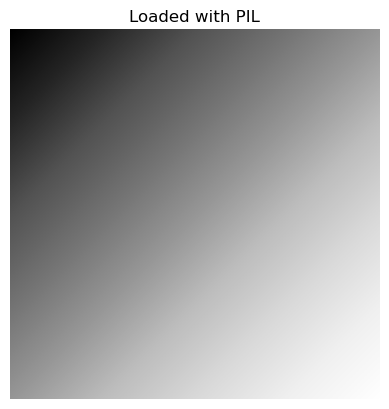

Successfully saved 'new_image.jpg' and 'new_image2.jpg'

--- Task 4: Array Data ---
OpenCV Image Shape: (256, 256, 3)
OpenCV Image Array:
 [[[  0   0   0]
  [  1   1   1]
  [  2   2   2]
  ...
  [253 253 253]
  [254 254 254]
  [255 255 255]]

 [[  1   1   1]
  [  0   0   0]
  [  3   3   3]
  ...
  [252 252 252]
  [255 255 255]
  [254 254 254]]

 [[  2   2   2]
  [  3   3   3]
  [  0   0   0]
  ...
  [255 255 255]
  [252 252 252]
  [253 253 253]]

 ...

 [[253 253 253]
  [252 252 252]
  [255 255 255]
  ...
  [  0   0   0]
  [  3   3   3]
  [  2   2   2]]

 [[254 254 254]
  [255 255 255]
  [252 252 252]
  ...
  [  3   3   3]
  [  0   0   0]
  [  1   1   1]]

 [[255 255 255]
  [254 254 254]
  [253 253 253]
  ...
  [  2   2   2]
  [  1   1   1]
  [  0   0   0]]]

PIL Image Array Shape: (256, 256)
PIL Image Array:
 [[  0   0   1 ... 126 127 127]
 [  0   1   1 ... 127 127 128]
 [  1   1   2 ... 127 128 128]
 ...
 [126 127 127 ... 253 253 254]
 [127 127 128 ... 253 254 254]
 [127 128 128 ... 

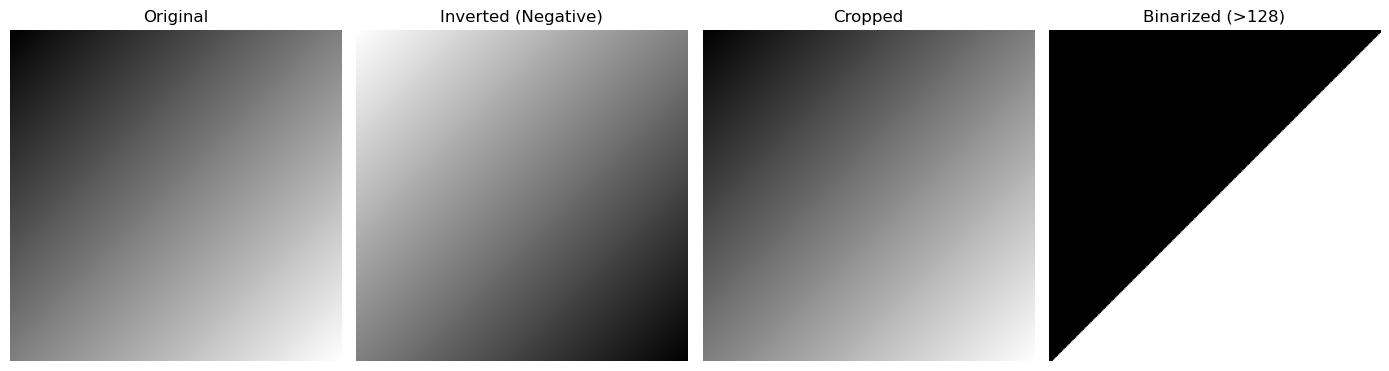

In [15]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ==========================================================
# 0. Path Resolution & Automatic Fallback
# ==========================================================
# Look in the current working directory, script directory, and an 'images' subfolder
base_dir = os.getcwd()
img_path_cv = os.path.join(base_dir, 'images', 'cameraman.tif')
img_path_pil = os.path.join(base_dir, 'images', 'lena_gray_256.tif')

# Fallback: check root if 'images/' subfolder does not exist
if not os.path.exists(img_path_cv):
    img_path_cv = os.path.join(base_dir, 'cameraman.tif')
if not os.path.exists(img_path_pil):
    img_path_pil = os.path.join(base_dir, 'lena_gray_256.tif')

# If neither file exists on disk, create dummy images so the lab can execute
if not os.path.exists(img_path_cv):
    print("Notice: 'cameraman.tif' not found. Creating a sample image to proceed...")
    dummy_img = (np.indices((256, 256))[0] ^ np.indices((256, 256))[1]).astype(np.uint8)
    cv2.imwrite('cameraman.tif', dummy_img)
    img_path_cv = 'cameraman.tif'

if not os.path.exists(img_path_pil):
    print("Notice: 'lena_gray_256.tif' not found. Creating a sample image to proceed...")
    dummy_img = (np.indices((256, 256))[0] * 0.5 + np.indices((256, 256))[1] * 0.5).astype(np.uint8)
    Image.fromarray(dummy_img).save('lena_gray_256.tif')
    img_path_pil = 'lena_gray_256.tif'


# ==========================================================
# Task #2: Loading and Visualizing Images
# ==========================================================
# a. Loading/reading an image using OpenCV
img = cv2.imread(img_path_cv)

# OpenCV loads color as BGR; convert if multi-channel, else keep as grayscale
if len(img.shape) == 3 and img.shape[2] == 3:
    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    is_gray = False
else:
    img_display = img
    is_gray = True

plt.figure("OpenCV Image")
plt.imshow(img_display, cmap='gray' if is_gray else None)
plt.title("Loaded with OpenCV")
plt.axis('off')
plt.show()

# b. Loading/reading image using PIL
img2 = Image.open(img_path_pil)

plt.figure("PIL Image")
plt.imshow(img2, cmap=cm.Greys_r)
plt.title("Loaded with PIL")
plt.axis('off')
plt.show()


# ==========================================================
# Task #3: Image Storing
# ==========================================================
# a. Saving image to disk using OpenCV
cv2.imwrite('new_image.jpg', img)

# b. Saving an image to disk using PIL
img2.save('new_image2.jpg')
print("Successfully saved 'new_image.jpg' and 'new_image2.jpg'")


# ==========================================================
# Task #4: Display Image as an Array
# ==========================================================
# Inspect OpenCV array
print("\n--- Task 4: Array Data ---")
print("OpenCV Image Shape:", img.shape)
print("OpenCV Image Array:\n", img)

# Convert PIL Image to NumPy array and inspect
img_array = np.array(img2)
print("\nPIL Image Array Shape:", img_array.shape)
print("PIL Image Array:\n", img_array)


# ==========================================================
# Section 4 Assessment: NumPy Array Operations on Images
# ==========================================================
print("\n--- Assessment: NumPy Image Operations ---")
print("Data type:", img_array.dtype)
print("Min pixel value:", img_array.min())
print("Max pixel value:", img_array.max())
print("Mean pixel intensity:", f"{img_array.mean():.2f}")

# 1. Negative / Invert Transformation
inverted_img = 255 - img_array

# 2. Slicing / Cropping
h, w = img_array.shape[:2]
cropped_img = img_array[h//4: 3*h//4, w//4: 3*w//4]

# 3. Thresholding / Binarization (> 128)
binary_img = np.where(img_array > 128, 255, 0).astype(np.uint8)

# Visualizing Operations
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(inverted_img, cmap='gray')
axes[1].set_title("Inverted (Negative)")
axes[2].imshow(cropped_img, cmap='gray')
axes[2].set_title("Cropped")
axes[3].imshow(binary_img, cmap='gray')
axes[3].set_title("Binarized (>128)")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()